En este ejemplo de regresión lineal simple, cargarás un conjunto de datos externos desde un repositorio de GitHub.

Luego, usarás los datos para entrenar un modelo de predicción simple para estimar el **salario**  de trabajadores basado en sus **años de experiencia**.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Salary_Data.csv"
salarydata = pd.read_csv(url)

Una vez importado el conjunto de datos, carguémoslo en una estructura de datos tabulares fácil de gestionar: ¡un **Pandas dataframe** es la elección perfecta!

In [2]:
salarydata.shape

(30, 2)

La función *shape* de un dataframe de Pandas nos dirá que el dataset es bastante pequeño. Únicamente 30 observaciones con 2 variables cada una: una de ellas es el atributo predictor *x* (**years of experience**) y la otra es la variable objetivo a predecir o etiqueta *y* (**salary**):

In [3]:
salarydata.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
# Separate the inputs X and labels y
X = salarydata[["YearsExperience"]]
y = salarydata["Salary"]

He aquí una visualización del dataset:

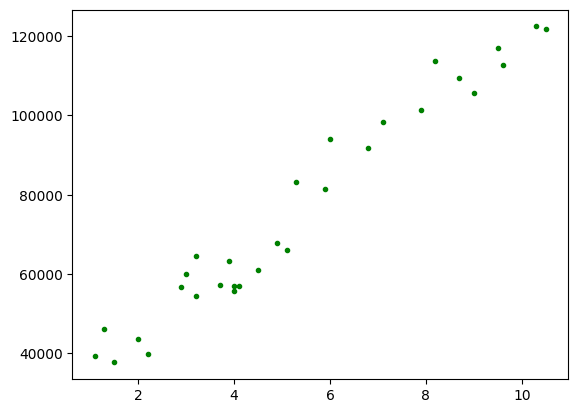

In [5]:
import matplotlib.pyplot as plt

plt.plot(X, y, "g.")
plt.show()

A continuación, a partir de los datos cargados, entrenaremos y construiremos un modelo de regresión lineal simple usando *scikit-learn*.

Después de entrenar el modelo, los atributos de clase "*coef_*" e "*intercept_*" permiten ver los parámetros del modelo aprendido, es decir, $m$ y $n$, respectivamente.

In [6]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression() # Import and initialize scikit-learn class for linear regression models
lin_reg.fit(X, y) # Train regression model
lin_reg.coef_, lin_reg.intercept_ # Take a look at the parameters learnt

(array([9449.96232146]), np.float64(25792.200198668696))

Por último, utilizamos el modelo aprendido para predecir la etiqueta **y** dados dos ejemplos: dos profesionales con 1,6 y 11,2 años de experiencia, respectivamente.

In [7]:
import numpy as np

X_test = np.array([[1.6], [11.2]])
y_test = lin_reg.predict(X_test) #Predict label for two instances: x=0 y x=2
y_test

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 40912.139913  , 131631.77819897])

También visualizamos el modelo aprendido -una función matemática equivalente a la ecuación de una recta- junto con los datos de entrenamiento utilizados, para observar cómo la línea se ajusta a dichos datos.

<function matplotlib.pyplot.show(close=None, block=None)>

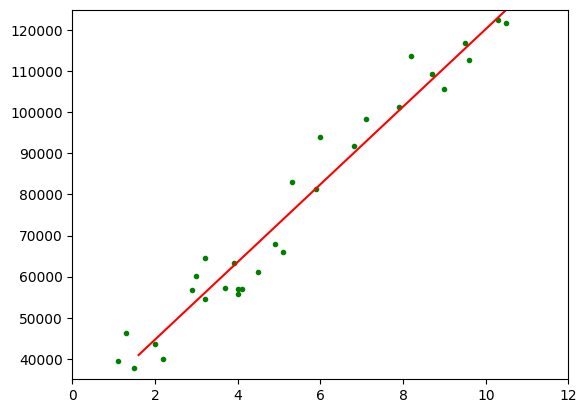

In [8]:
plt.plot(X, y, "g.")
plt.plot(X_test, y_test, "r-") # To visualize the regression line, it is enough to indicate two points (x,y) belonging to it.
plt.axis([0, 12, 35000, 125000])
plt.show